✅ Dataset loaded: (1156, 794)
🎯 Using target column: initial_assessment_screening_screening_clinical_dementia_rating,013_global_cdr
✅ Using 652 features for modeling.
🔖 Label mapping: {np.float64(0.0): 0, np.float64(0.5): 1, np.float64(1.0): 2}
⚖️ Class distribution before SMOTE: [317 291   6]
✅ Class distribution after SMOTE: [317 317 317]

✅ CCNA Model Accuracy: 0.662

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.75      0.70        79
           1       0.66      0.59      0.62        73
           2       0.00      0.00      0.00         2

    accuracy                           0.66       154
   macro avg       0.44      0.45      0.44       154
weighted avg       0.65      0.66      0.66       154

📁 Saved predictions to 'ccna_pred_probs.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


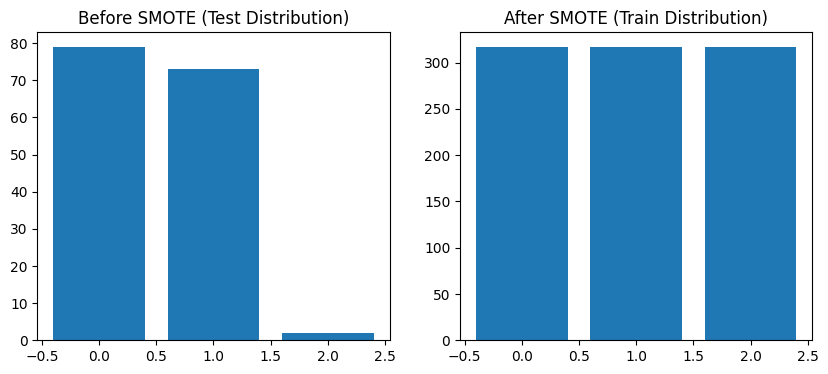

In [ ]:
# ==============================================================
#     CCNA MODEL — GLOBAL CDR Target + SMOTE Balancing
# ==============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# ✅ Step 1: Load dataset
df = pd.read_csv("/content/data-2025-10-22T16_13_05.599Z.csv", low_memory=False)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("✅ Dataset loaded:", df.shape)

# ✅ Step 2: Identify the target column (Global CDR)
target_col = "initial_assessment_screening_screening_clinical_dementia_rating,013_global_cdr"
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(float)
print(f"🎯 Using target column: {target_col}")

# ✅ Step 3: Drop irrelevant columns (CDR components, IDs, Dates, etc.)
drop_patterns = [
    "clinical_dementia_rating", "date", "time", "examiner", "guid",
    "subject", "candidate_id", "visit", "window_difference"
]
cols_to_drop = [c for c in df.columns if any(p in c for p in drop_patterns)]
cols_to_drop = [c for c in cols_to_drop if c != target_col]

df = df.drop(columns=cols_to_drop, errors="ignore")

# ✅ Step 4: Encode categorical features and fill missing
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("Missing")
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    else:
        df[col] = df[col].fillna(df[col].median())

# ✅ Step 5: Split features and target
X = df.drop(columns=[target_col])
y = df[target_col]
print(f"✅ Using {X.shape[1]} features for modeling.")

# ✅ Step 6: Normalize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Step 7: Prepare labels (convert to class indices)
unique_vals = sorted(y.unique())
label_map = {v: i for i, v in enumerate(unique_vals)}
y_cls = y.map(label_map).astype(int)
print("🔖 Label mapping:", label_map)

# ✅ Step 8: Train-test split
can_stratify = y_cls.value_counts().min() >= 2
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cls, test_size=0.2, random_state=42,
    stratify=y_cls if can_stratify else None
)

# ✅ Step 9: Apply SMOTE to balance training data
print("⚖️ Class distribution before SMOTE:", np.bincount(y_train))
smote = SMOTE(random_state=42, k_neighbors=min(5, len(np.unique(y_train))-1))
X_train, y_train = smote.fit_resample(X_train, y_train)
print("✅ Class distribution after SMOTE:", np.bincount(y_train))

# ✅ Step 10: Train XGBoost model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)
model.fit(X_train, y_train)

# ✅ Step 11: Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ CCNA Model Accuracy: {acc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ✅ Step 12: Save predictions for cross-cohort comparison
out = pd.DataFrame(y_prob, columns=[f"ccna_prob_{i}" for i in range(y_prob.shape[1])])
out["true_label"] = y_test.values
out["ccna_pred"] = y_pred
out["ID"] = np.arange(len(y_test))
out.to_csv("ccna_pred_probs.csv", index=False)
print("📁 Saved predictions to 'ccna_pred_probs.csv'")

# ✅ Step 13 (Optional): Visualize class balance before/after SMOTE
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(np.arange(len(np.bincount(y_test))), np.bincount(y_test))
ax[0].set_title("Before SMOTE (Test Distribution)")
ax[1].bar(np.arange(len(np.bincount(y_train))), np.bincount(y_train))
ax[1].set_title("After SMOTE (Train Distribution)")
plt.show()
